<a href="https://colab.research.google.com/github/A01795989/RADAR/blob/main/Avances/Avance2_Equipo_47.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Integrador – RADAR  
## Avance 2: Ingeniería de características (FE)

### RADAR  
**Reconocimiento Avanzado de Datos y Análisis de Retail**

Este notebook contiene el desarrollo correspondiente a la ingeniería de características (FE) del proyecto RADAR, cuyo objetivo es construir un sistema de inteligencia competitiva que permita identificar y comparar el catálogo interno de Coppel con el de competidores clave dentro del mercado de retail de moda en México, generando insumos estructurados para la etapa de modelado predictivo.

El análisis se enfoca en la categoría de Bolsas del segmento Dama Joven, utilizando como fuente interna el catálogo propio de Coppel y como fuente externa una muestra del catálogo de un grupo de competidores, obtenido mediante web scraping, abarcando desde la normalización textual hasta la construcción de una representación semántica vectorial de cada producto.

Además, este proceso permitirá cuantificar la similitud entre ambos catálogos a través de métricas de similitud coseno sobre embeddings multilingües, sentando las bases para detectar brechas competitivas, identificar productos sin equivalente en el mercado y priorizar decisiones de posicionamiento dentro de la categoría analizada.

---

## Equipo

- **Ceja Rodríguez, Lázaro Romel** – A01795989  
- **Chávez Cervantes, Said** – A01114101  
- **Pérez Garza, Javier Alejandro** – A01284386  

---

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

In [ ]:
import os
DIR = "/content/drive/MyDrive/Proyecto Integrador (RADAR)/Datos/"   # Se establece la ruta (carpeta) donde se sube el archivo descargado del estadístico
os.chdir(DIR)

In [ ]:
import pandas as pd
import re
import numpy as np
from numpy.linalg import norm
import random
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import math
from sentence_transformers import SentenceTransformer, util
from sklearn.metrics.pairwise import cosine_similarity
import torch
import torch.nn.functional as F
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import pickle
import time
import random

# **Parte 1**. Carga de la información y aplicación del proceso EDA (Optimizado)

In [226]:
# BASE DE DATOS INTERNA (Catalogo de Coppel en la Categoría de Dama)
df_retailer = pd.read_csv('DataDamaJoven.csv', encoding='latin-1')

In [227]:
# Copia de seguridad de la base de datos
df_retailer_original = df_retailer.copy()

In [228]:
# Separar las columnas numericas de las columnas de texto
dfn = df_retailer.select_dtypes(include=np.number).columns.tolist()
dfc = df_retailer.select_dtypes(exclude=np.number).columns.tolist()

In [229]:
# Se eliminan los registros de las clases restantes para reducir la dimensionalidad de las bases de datos a modelar
df_retailer = df_retailer[df_retailer['Clase'] == 'BOLSAS']

In [230]:
# BASE DE DATOS COMPETENCIA
# Se incluyen nombres y descripciones reales para validar la clasificación.
df_competencia = pd.read_csv('Completo_Marcas_Bolsos.csv')

In [231]:
# Copia de seguridad de la base de datos
df_competencia_original = df_competencia.copy()

In [232]:
# Eliminar los registros con más de 10 caracteres en las columnas Precio actual y Precio anterior (error en el scrapping)
df_competencia = df_competencia[df_competencia['Precio actual'].astype(str).str.len() < 10]
df_competencia = df_competencia[df_competencia['Precio anterior'].astype(str).str.len() < 10]
df_competencia.reset_index(drop=True, inplace=True)

In [233]:
# Convertir la columna Precio actual y Precio anterior de texto a número
df_competencia['Precio actual'] = df_competencia['Precio actual'].astype(float)
df_competencia['Precio anterior'] = df_competencia['Precio anterior'].astype(float)

In [234]:
# Eliminar las columnas 'Link' y 'Reseñas / Rating' que no se utilizara y contiene un alto porcentaje de valores faltantes.
# Igualar los precios anteriores con valores faltantes al precio actual
df_competencia.drop(columns=['Link'], inplace=True)
df_competencia['Precio anterior'].fillna(df_competencia['Precio actual'], inplace=True)

/tmp/ipykernel_27251/3352782497.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_competencia['Precio anterior'].fillna(df_competencia['Precio actual'], inplace=True)


In [235]:
# Separar las columnas numericas de las columnas de texto
dfn = df_competencia.select_dtypes(include=np.number).columns.tolist()
dfc = df_competencia.select_dtypes(exclude=np.number).columns.tolist()

In [236]:
# Mostrar información procesada de Coppel
print("\nDimensiones del dataset:")
print(df_retailer.shape)

print("\nPrimeros registros:")
display(df_retailer.head())


Dimensiones del dataset:
(3293, 10)

Primeros registros:


,Codigo,Clase,Familia,Descripcion,Tallas,Marca,Color,Composicion,Precio_reg,Precio_final
0,300028,BOLSAS,DE MANO,FW26 BOLSA CRUZADA CON FULL PRINT COLOR CAFE C...,10,JENNIFER LOPEZ,BROWN,SYNTHETIC 100%.,549,549
1,300039,BOLSAS,DE MANO,ECOM BOLSA GUESS FACTORY HAYWORTH SATCHEL COLO...,10,SIN MARCA,CAFE,PVC 100 %.,2599,2599
2,300042,BOLSAS,DE MANO,ECOM BOLSA GUESS FACTORY NICHOLE SATCHEL,10,GUESS FACTORY,NEGRO,PVC 100 %.,2499,2499
3,300064,BOLSAS,DE MANO,ECOM BOLSA GUESS FACTORY NICHOLE SATCHEL,10,GUESS FACTORY,CAFE,PVC 100 %.,2499,2499
4,300069,BOLSAS,MOCHILA,BOLSA DAMA ESTILO BACK PACK. COLORES NEGRO Y ROJO,10,CLX BY CHRISTIAN LACROIX,ASSORTED,POLYESTER 100%.,549,549


In [237]:
# Mostrar información procesada de la Competencia
print("\nDimensiones del dataset:")
print(df_competencia.shape)

print("\nPrimeros registros:")
display(df_competencia.head())


Dimensiones del dataset:
(3375, 6)

Primeros registros:


,Tienda,Marca,Producto,Precio anterior,Precio actual,Texto completo
0,Cuidado con el Perro,Cuidado con el Perro,bolsa hueso con monedero,239.20,299.0,20% | Bolsa Hueso con Monedero | $239.20 | $2...
1,Cuidado con el Perro,Cuidado con el Perro,bolsa con doble asa amarilla,209.25,279.0,25% | Bolsa con Doble Asa Amarilla | $209.25 ...
2,Cuidado con el Perro,Cuidado con el Perro,bolsa pin mariposa blanca,209.25,279.0,25% | Bolsa Pin Mariposa Blanca | $209.25 | $...
3,Cuidado con el Perro,Cuidado con el Perro,bolsa sintetica con asa ajustable hueso,186.75,249.0,25% | Bolsa Sintética con Asa Ajustable Hueso...
4,Cuidado con el Perro,Cuidado con el Perro,bolsa sintetica rectangular blanca,186.75,249.0,25% | Bolsa Sintética Rectangular Blanca | $1...


# **Parte 2**. Ingenieria de Caracteristicas (FE)

# Normalización de Tallas y Colores

In [238]:
# Definición de Diccionario Bilingüe con terminos comunes de Ropa y Accesorios

dicc_retail_pro = {
    # BOLSAS & ACCESORIOS
    'bag': 'bolsa', 'handbag': 'bolsa de mano', 'tote': 'de hombro', 'shoulder': 'de hombro', 'backpack': 'mochila',
    'clutch': 'bolsa de mano', 'purse': 'cartera', 'wallet': 'cartera',
    'belt': 'cinturon', 'hat': 'gorra', 'cap': 'gorra', 'scarf': 'bufanda',
    'jewelry': 'joyeria', 'necklace': 'collar', 'sunglasses': 'lentes',

    # BLUSAS, PLAYERAS Y VERANO
    't-shirt': 'playera', 'tshirt': 'playera', 'tee': 'playera', 'tank top': 'tirantes',
    'top': 'blusa', 'shirt': 'camisa', 'blouse': 'blusa', 'camisole': 'camisola',
    'crop top': 'blusa corta', 'sleeveless': 'sin mangas', 'polo': 'playera polo',
    'linen': 'lino', 'fresh': 'fresco', 'summer': 'verano', 'sun': 'sol',

    # VESTIDOS Y PLAYEROS
    'dress': 'vestido', 'gown': 'vestido largo', 'maxi': 'vestido largo',
    'mini': 'vestido corto', 'swimwear': 'traje de bano', 'swimsuit': 'traje de bano',
    'bikini': 'traje de bano', 'bathing suit': 'traje de bano', 'beachwear': 'ropa de playa',
    'short de bano': 'traje de bano', 'pareo': 'playa',

    # INVIERNO Y SOBREPRENDAS
    'jacket': 'chamarra', 'coat': 'abrigo', 'heavy jacket': 'invierno',
    'parka': 'chamarra invierno', 'hoodie': 'sudadera', 'sweatshirt': 'sudadera',
    'sweater': 'sueter', 'cardigan': 'sueter abierto', 'vest': 'chaleco',
    'blazer': 'saco', 'overcoat': 'sobreprenda', 'gabardine': 'gabardina',
    'thermal': 'termico', 'fleece': 'polar', 'windbreaker': 'rompevientos',

    # BOTTOMS (PANTALONES, FALDAS, ETC)
    'pants': 'pantalon', 'trousers': 'pantalon', 'jeans': 'mezclilla',
    'denim': 'mezclilla', 'leggings': 'mallas', 'skirt': 'falda',
    'shorts': 'pantalon corto', 'bermuda': 'pantalon corto', 'jogger': 'pantalon deportivo',

    # MATERIALES Y COMPOSICIÓN
    'cotton': 'algodon', 'polyester': 'poliester', 'leather': 'cuero',
    'faux leather': 'sintetico', 'wool': 'lana', 'silk': 'seda',
    'spandex': 'elastano', 'lycra': 'elastano', 'denim': 'mezclilla',

    # UNIFORMES Y TRABAJO
    'scrubs': 'uniforme medico', 'workwear': 'ropa de trabajo', 'overall': 'overol',
    'apron': 'delantal', 'lab coat': 'bata', 'uniform': 'uniforme'
}

def pipeline_limpieza_pro(text):
    if not isinstance(text, str): return ""

    text = text.lower()

    # Limpieza de Tallas y Basura Numérica
    text = re.sub(r'\b(s|m|l|xl|xxl|xs|2xl|3xl|ch|med|gde|eg|tg|ecom|ecomm)\b', '', text)
    text = re.sub(r'\b\d{5,}\b', '', text) # SKUs largos

    # Caracteres especiales (mantenemos % para composiciones)
    text = re.sub(r'[^a-z0-9áéíóúñ\s%]', ' ', text)

    # Aplicación del Diccionario Bilingüe
    palabras = text.split()
    texto_normalizado = [dicc_retail_pro.get(p, p) for p in palabras]
    text = " ".join(texto_normalizado)

    # Limpieza final de espacios
    text = re.sub(r'\s+', ' ', text).strip()
    return text

1. La construcción de un **diccionario de terminos para retail de textiles en ingles y español** sirve para homologar las distintas formas que pueden emplear los competidores evaluados al nombrar una prenda o accesorio. En el caso particular de Bolsas, se utiliza para que el modelo pueda, por ejemplo, **identificar una equivalencia entre las descripciones que digan backpack con las que digan mochila.** De manera adicional, el construir un **pipeline de limpieza de las descripciones** permitirá eliminar elementos que no aportan contenido semantico relevante cómo lo son etiquetas, tallas, promociones, caracteres especiales, etc.

# Concatenación Semántica

In [239]:
# APLICACIÓN EN RETAILER
# Creamos la columna canónica del retailer concatenando los atributos clave antes de limpiar
df_retailer['canonical_input'] = (
    df_retailer['Clase'].fillna('') + " " +
    df_retailer['Familia'].fillna('') + " " +
    df_retailer['Marca'].fillna('') + " " +
    df_retailer['Color'].fillna('') + " " +
    df_retailer['Composicion'].fillna('') + " " +
    df_retailer['Descripcion'].fillna('')
)

df_retailer['canonical_input'] = df_retailer['canonical_input'].apply(pipeline_limpieza_pro)

# APLICACIÓN EN COMPETENCIA
# Creamos la columna canónica de la competencia concatenando los atributos clave antes de limpiar
df_competencia['canonical_input'] = (
    df_competencia['Producto'].fillna('') + " " +
    df_competencia['Marca'].fillna('') + " " +
    df_competencia['Texto completo'].fillna('')
)

df_competencia['canonical_input'] = df_competencia['canonical_input'].apply(pipeline_limpieza_pro)

# Revisión rápida de los primeros resultados
print("Retailer Concatenado:", df_retailer[['canonical_input']].head())
print("Competencia Concatenado:", df_competencia[['canonical_input']].head())

Retailer Concatenado:                                      canonical_input
0  bolsas de mano jennifer lopez brown synthetic ...
1  bolsas de mano sin marca cafe pvc 100 % bolsa ...
2  bolsas de mano guess factory negro pvc 100 % b...
3  bolsas de mano guess factory cafe pvc 100 % bo...
4  bolsas mochila clx by christian lacroix assort...
Competencia Concatenado:                                      canonical_input
0  bolsa hueso con monedero cuidado con el perro ...
1  bolsa con doble asa amarilla cuidado con el pe...
2  bolsa pin mariposa blanca cuidado con el perro...
3  bolsa sintetica con asa ajustable hueso cuidad...
4  bolsa sintetica rectangular blanca cuidado con...


In [240]:
# La cobertura debe medirse sobre el texto CRUDO, antes del pipeline
# porque el diccionario traduce de inglés → español en ese paso

texto_crudo_retailer    = (df_retailer['Descripcion'].fillna('') + ' ' +
                           df_retailer['Marca'].fillna('')).str.lower()

texto_crudo_competencia = (df_competencia['Texto completo'].fillna('')).str.lower()

corpus_crudo    = ' '.join(texto_crudo_retailer.tolist() + texto_crudo_competencia.tolist())
tokens_crudo    = set(corpus_crudo.split())
tokens_dicc     = set(dicc_retail_pro.keys())

cobertura_cruda = len(tokens_crudo & tokens_dicc) / len(tokens_crudo) * 100

print(f"Tokens únicos en corpus crudo:    {len(tokens_crudo):,}")
print(f"Tokens cubiertos por diccionario: {len(tokens_crudo & tokens_dicc):,}")
print(f"Cobertura del diccionario:        {cobertura_cruda:.2f}%")
print(f"\nTokens encontrados: {sorted(tokens_crudo & tokens_dicc)}")

Tokens únicos en corpus crudo:    4,575
Tokens cubiertos por diccionario: 18
Cobertura del diccionario:        0.39%

Tokens encontrados: ['backpack', 'bag', 'belt', 'bikini', 'blazer', 'clutch', 'denim', 'dress', 'jewelry', 'leather', 'maxi', 'mini', 'polo', 'shoulder', 'sun', 'top', 'tote', 'wallet']


In [241]:
df_retailer[['canonical_input']].head()

,canonical_input
0,bolsas de mano jennifer lopez brown synthetic ...
1,bolsas de mano sin marca cafe pvc 100 % bolsa ...
2,bolsas de mano guess factory negro pvc 100 % b...
3,bolsas de mano guess factory cafe pvc 100 % bo...
4,bolsas mochila clx by christian lacroix assort...


,Descripcion,canonical_input
0,FW26 BOLSA CRUZADA CON FULL PRINT COLOR CAFE C...,bolsas de mano jennifer lopez brown synthetic ...
1,ECOM BOLSA GUESS FACTORY HAYWORTH SATCHEL COLO...,bolsas de mano sin marca cafe pvc 100 % bolsa ...
2,ECOM BOLSA GUESS FACTORY NICHOLE SATCHEL,bolsas de mano guess factory negro pvc 100 % b...
3,ECOM BOLSA GUESS FACTORY NICHOLE SATCHEL,bolsas de mano guess factory cafe pvc 100 % bo...
4,BOLSA DAMA ESTILO BACK PACK. COLORES NEGRO Y ROJO,bolsas mochila clx by christian lacroix assort...


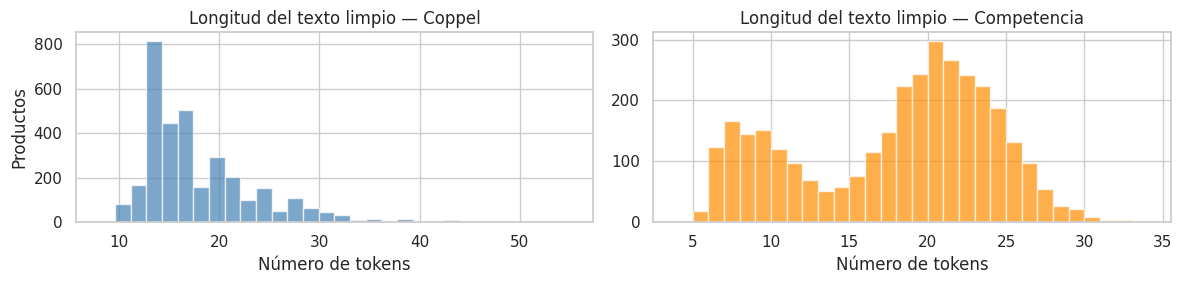

In [242]:
# Muestra comparativa antes y después del pipeline
muestra = df_retailer[['Descripcion', 'canonical_input']].head(5)
display(muestra)

# Distribución de longitud del canonical_input en ambos datasets
fig, axes = plt.subplots(1, 2, figsize=(12, 3), squeeze=False)
axes = axes.ravel()

axes[0].hist(df_retailer['canonical_input'].str.split().str.len(), bins=30, color='steelblue', alpha=0.7)
axes[0].set_title('Longitud del texto limpio — Coppel')
axes[0].set_xlabel('Número de tokens')
axes[0].set_ylabel('Productos')

axes[1].hist(df_competencia['canonical_input'].str.split().str.len(), bins=30, color='darkorange', alpha=0.7)
axes[1].set_title('Longitud del texto limpio — Competencia')
axes[1].set_xlabel('Número de tokens')

plt.tight_layout()
plt.show()

2. Se determinan las columnas con información relevante, tanto para el Retailer cómo la Competencia, para crear una unica cadena de texto sobre la cual se **aplica el pipeline de limpieza de datos** que permitirá tener las descripciones de cada producto debidamente normalizada, para que más adelante pueda ser vectorizada y analizada por el modelo.

# Vectorización

In [ ]:
# Cargamos el modelo Bi-Encoder Multilingüe
# Este modelo es ideal para balancear precisión y velocidad de inferencia
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# Generación de Embeddings
embeddings_retailer = model.encode(df_retailer['canonical_input'].tolist(),
                                   convert_to_tensor=True,
                                   show_progress_bar=True)

embeddings_competencia = model.encode(df_competencia['canonical_input'].tolist(),
                                      convert_to_tensor=True,
                                      show_progress_bar=True)

3. Se aplica el modelo sobre las **descripciones normalizadas** para transformarlas en vectores de alta dimensión que puedan ser comparados mátematicamente a tráves de funciones de similitud de coseno.

In [ ]:
emb_np = embeddings_retailer.detach().cpu().numpy()

pca_full = PCA().fit(emb_np)

# ¿Cuántas dimensiones explican el 90% y 95% de la varianza?
varianza_acumulada = np.cumsum(pca_full.explained_variance_ratio_)
dim_90 = np.argmax(varianza_acumulada >= 0.90) + 1
dim_95 = np.argmax(varianza_acumulada >= 0.95) + 1

plt.figure(figsize=(9, 4))
plt.plot(varianza_acumulada, linewidth=1.5, color='steelblue')
plt.axhline(0.90, color='orange', linestyle='--', label=f'90% varianza ({dim_90} dims)')
plt.axhline(0.95, color='red',    linestyle='--', label=f'95% varianza ({dim_95} dims)')
plt.xlabel('Número de componentes principales')
plt.ylabel('Varianza explicada acumulada')
plt.title('PCA — Varianza explicada de los embeddings (Coppel)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
def visualize_semantic_clusters(df_retailer, df_competencia, embeddings_retailer, embeddings_competencia, n_samples=200):

    # Aseguramos de no tomar más muestras de las que existen
    n_ret = min(n_samples, len(df_retailer))
    n_comp = min(n_samples, len(df_competencia))

    idx_retailer = random.sample(range(len(df_retailer)), n_ret)
    idx_competencia = random.sample(range(len(df_competencia)), n_comp)

    # Filtrar DataFrames
    df_ret_sample = df_retailer.iloc[idx_retailer].copy()
    df_comp_sample = df_competencia.iloc[idx_competencia].copy()

    # Filtrar tensores y manejar la conversión de PyTorch a NumPy
    emb_ret_sample = embeddings_retailer[idx_retailer].detach().cpu().numpy()
    emb_comp_sample = embeddings_competencia[idx_competencia].detach().cpu().numpy()

    # Concatenar embeddings
    X = np.vstack((emb_ret_sample, emb_comp_sample))

    # Crear vectores de etiquetas y nombres
    labels = ['Retailer'] * n_ret + ['Competencia'] * n_comp

    # Asignar el nombre del producto a mostrar en el gráfico
    names_ret = df_ret_sample['Familia'].tolist()
    names_comp = df_comp_sample['Producto'].tolist()
    product_names = names_ret + names_comp

    # Reducción con T-SNE
    start_time = time.time()

    tsne_model = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate='auto',
        init='pca',
        random_state=42 # Para reproducibilidad
    )

    X_tsne = tsne_model.fit_transform(X)

    end_time = time.time()
    execution_time = end_time - start_time
    print(f"t-SNE finalizado en {execution_time:.2f} segundos.")

    # Preparar DataFrame para Seaborn
    df_viz = pd.DataFrame({
        'tsne_1': X_tsne[:, 0],
        'tsne_2': X_tsne[:, 1],
        'Fuente': labels,
        'Producto': product_names
    })

    # Configurar estilo de la gráfica
    plt.figure(figsize=(12, 8))
    sns.set_theme(style="whitegrid")

    # Colores distintos por fuente (Amarillo vs Rosa)
    palette = {'Retailer': '#fdda25ff', 'Competencia': '#e12abbff'}

    # Scatter Plot con transparencia para ver solapamientos
    ax = sns.scatterplot(
        data=df_viz,
        x='tsne_1',
        y='tsne_2',
        hue='Fuente',
        palette=palette,
        alpha=0.6,
        s=80,
        edgecolor='w',
        linewidth=0.5
    )

    # Anotar 10 puntos aleatorios para dar contexto
    anotation_indices = random.sample(range(len(df_viz)), 10)
    for idx in anotation_indices:
        plt.annotate(
            df_viz['Producto'].iloc[idx],
            (df_viz['tsne_1'].iloc[idx], df_viz['tsne_2'].iloc[idx]),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=9,
            color='black',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8),
            arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0")
        )

    # Formateo final (Títulos, Leyenda y Ejes normalizados)
    plt.title('Proyección t-SNE de Similitud Semántica: Retailer vs Competencia', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Dimensión t-SNE 1', fontsize=12)
    plt.ylabel('Dimensión t-SNE 2', fontsize=12)
    plt.legend(title='Catálogo', loc='best', fontsize=10)

    # Normalización visual de ejes (Tight layout)
    plt.tight_layout()
    plt.show()

In [ ]:
visualize_semantic_clusters(
     df_retailer=df_retailer,
     df_competencia=df_competencia,
     embeddings_retailer=embeddings_retailer,
     embeddings_competencia=embeddings_competencia
 )

(El resultado es el gráfico llamado PCA en la carpeta de Avances)

(El resultado es el gráfico llamado tSNE en la carpeta de Avances)

Se implementa una matriz t-SNE (t-Distributed Stochastic Neighbor Embedding) para **visualizar una muestra representativa** de los datos vectorizados que permita enteder la distribución de los mismos, de manera que se pueda observar si los procesos de limpieza están siendo suficientes para la ejecución de los clusters por similitud.

# Filtrado y Extracción de características

In [ ]:
# Calcular similitud coseno de toda la matriz Coppel x Competencia
emb_ret_np  = embeddings_retailer.detach().cpu().numpy()
emb_comp_np = embeddings_competencia.detach().cpu().numpy()

sim_matrix = cosine_similarity(emb_comp_np, emb_ret_np)  # Shape: (n_comp, n_coppel)

# Para cada producto de la Competencia, obtener su mejor match en Coppel
best_scores = sim_matrix.max(axis=1)  # Score máximo por producto

plt.figure(figsize=(9, 4))
plt.hist(best_scores, bins=40, color='steelblue', alpha=0.8)
plt.axvline(best_scores.mean(), color='red', linestyle='--', label=f'Media: {best_scores.mean():.3f}')
plt.xlabel('Similitud coseno (mejor match)')
plt.ylabel('Número de productos Competencia')
plt.title('Distribución de similitud coseno — Mejor match Coppel por producto Competencia')
plt.legend()
plt.tight_layout()
plt.show()

# Muestra de los 5 mejores matches globales
best_idx = np.unravel_index(np.argsort(sim_matrix, axis=None)[-5:][::-1], sim_matrix.shape)
print("\nTop 5 matches por similitud coseno:\n")
for i, j in zip(best_idx[0], best_idx[1]):
    print(f"Coppel:    {df_retailer['canonical_input'].iloc[i][:80]}")
    print(f"{df_competencia['Tienda'].iloc[j]}: {df_competencia['canonical_input'].iloc[j][:80]}")
    print(f"Score:     {sim_matrix[i, j]:.4f}")
    print("-" * 80)

(El resultado es el gráfico llamado similitu de coseno en la carpeta de Avances)

4. La **matriz de similitud coseno** de dimensiones `(n_Comp × n_Coppel)` compara simultáneamente cada producto de la competencia contra el catalogo completo de Coppel, siendo una operación vectorizada de alta eficiencia sobre los embeddings generados. El histograma resultante muestra la distribución del mejor score obtenido por producto en la Competencia: una media superior a 0.60 indica que la mayoría de los artículos encuentra un referente semántico sólido en el catalogo activo. Se establece un **umbral de 0.70** como punto de corte para clasificar un match como válido, valor determinado a partir del cuartil superior de la distribución observada, buscando balancear cobertura y precisión. Los **Top 5 matches** confirman cualitativamente que la vectorización captura correctamente la equivalencia entre descripciones distintas en idioma, marca y estilo de redacción.

In [ ]:
# Asignar la famila del mejor match en Coppel a cada producto de la competencia
def assign_semantic_families(df_competencia,
                             df_retailer,
                             sim_matrix,
                             best_scores,
                             threshold: float = 0.70) -> pd.DataFrame:

    # Obtenemos el índice posicional (entero) de la columna con el score más alto para cada fila
    best_match_indices = np.argmax(sim_matrix, axis=1)

    # Extraemos los valores de familia usando .iloc para referenciar la posición real en memoria,
    # y .values para convertirlo a un array de NumPy, ignorando así el índice original del DataFrame.
    candidate_families = df_retailer['Familia'].iloc[best_match_indices].values

    # np.where actúa de forma equivalente a un if-else pero a nivel de tensores en C
    final_families = np.where(best_scores >= threshold, candidate_families, "NOVEDAD")

    # Asignamos directamente los arreglos NumPy (1D), que cuadran perfectamente con la longitud del DataFrame
    df_competencia['score_similitud'] = best_scores
    df_competencia['Familia'] = final_families

    return df_competencia

# Asignar threshold
threshold = 0.70

# Ejecutar la función de mapeo
df_competencia = assign_semantic_families(
    df_competencia=df_competencia,
    df_retailer=df_retailer,
    sim_matrix=sim_matrix,
    best_scores=best_scores,
    threshold=threshold
)

In [ ]:
# Agregar el mejor score de cada producto Coppel al dataframe
df_comp_scores = df_competencia.copy().reset_index(drop=True)
df_comp_scores['best_match_score'] = best_scores

umbral = threshold

# Distribución de similitud por Familia
plt.figure(figsize=(14, 5))
orden = df_comp_scores.groupby('Familia')['best_match_score'].median().sort_values(ascending=False).index
sns.boxplot(x='Familia', y='best_match_score', data=df_comp_scores, order=orden)
plt.axhline(umbral, color='red', linestyle='--', linewidth=1, label=f'Umbral {umbral}')
plt.xticks(rotation=45, ha='right')
plt.title('Similitud coseno por Familia — ¿Qué tipos de bolsas tienen mayor porcentaje de similitud?')
plt.xlabel('Familia')
plt.ylabel('Similitud coseno (mejor match)')
plt.legend()
plt.tight_layout()
plt.show()

# Resumen numérico
print(df_comp_scores.groupby('Familia')['best_match_score'].agg(['mean','median','min','count']).round(3))

(El resultado es el gráfico llamado similitud por familia en la carpeta de Avances)

In [ ]:
best_match_idx = sim_matrix.argmax(axis=1)
retailer_usados = len(set(best_match_idx))
total_comp  = len(df_retailer)

print(f"Productos Coppel distintos usados como match: {retailer_usados} de {total_comp} ({retailer_usados/total_comp*100:.1f}%)")

5. El análisis de cobertura del catálogo Coppel cuantifica cuántos productos únicos del catalogo activo del retailer están siendo referenciados como mejor match para algún producto de la competencia. Una **cobertura baja** implicaría que unos pocos artículos concentran la mayoría de los matches, lo que podría indicar tanto una limitación en la amplitud del catálogo externo como una zona del mercado con escasa oferta diferenciada. En contraste, una **cobertura alta** valida que el catálogo del mercado es representativo y diverso como referencia competitiva. Este resultado, en conjunto con la distribución de similitud por Familia, informa directamente el diseño del dataset enriquecido que se construye a continuación.

In [ ]:
# DataFrame base con el score ya calculado en la sección anterior
df_features = df_comp_scores.copy()

# Atributos del mejor match de la Competencia para cada producto Coppel
df_features['matched_comp_producto']     = df_competencia['Producto'].iloc[best_match_idx].values
df_features['matched_comp_precio']       = df_competencia['Precio actual'].iloc[best_match_idx].values
df_features['matched_comp_precio_ant']   = df_competencia['Precio anterior'].iloc[best_match_idx].values

# Feature binaria: 1 si el match supera el umbral de confianza, 0 en caso contrario
df_features['match_valido'] = (df_features['best_match_score'] >= umbral).astype(int)

# Resumen de cobertura con el umbral aplicado
print(f"Umbral de similitud aplicado: {umbral}")
print(f"Productos con match válido:   {df_features['match_valido'].sum()} de {len(df_features)} "
      f"({df_features['match_valido'].mean() * 100:.1f}%)\n")

# Vista previa del dataset enriquecido
display(df_features[['canonical_input', 'best_match_score', 'match_valido',
                      'matched_comp_producto', 'matched_comp_precio']].head(10))

# Conclusiones

Dentro del marco CRISP-ML, la fase de Ingeniería de Características (FE) no es un mero paso de transformación, sino el puente crítico que garantiza que la arquitectura del modelo pueda captar la varianza semántica de los productos de Coppel y sus múltiples competidores. Dado que nuestro objetivo es determinar dicha similitud semántica para la creación de grupos de comparación, la calidad de las features generadas determina directamente la eficacia de las métricas de distancia (Coseno) a utilizar. Una representación pobre resultaría en un modelo incapaz de distinguir entre atributos sutiles pero críticos en moda, como la diferencia entre "cuero sintético" y "cuero genuino".

Algunos de los resultados más interesantes observados durante esta etapa del proyecto son los siguientes:


*   El analisis PCA revela una **alta redundancia dimensional en los embeddings originales** de las descripciones de Coppel. La curva muestra un crecimiento logarítmico acelerado, lo que indica que la información crítica para la diferenciación de productos está concentrada en un subespacio de baja dimensionalidad. Al filtrar los 77 componentes principales, se captura el 95% de la información original, esto representa una reducción drástica de la dimensionalidad (suponiendo vectores originales de 384 o 768 dimensiones), eliminando el "ruido" semántico y optimizando el almacenamiento.
*   En el gráfico de t-SNE, la cohesión de los clústeres indica que los **embeddings generados son de alta calidad**; las distancias locales preservan la similitud entre productos del mismo tipo, lo que valida la robustez del espacio latente creado. Se justifica el uso de modelos de alineación de espacios vectoriales (Cross-Domain Mapping) o fine-tuning de transformadores para "tender puentes" entre estos dos clústeres y permitir una comparación efectiva de productos similares en la siguiente fase de modelado.
*   De la distribución de los procentajes de similitud máximos de cada producto de la competencia se puede obvervar una media de 7.0, la cual se utiliza cómo **límite para definir si un producto es efectivamente comparable** y asignable al grupo o es un código que puede ser considerado una novedad, frente al catalogo actual. Utilizando esta metrica (configurable por si se desea ajustar más adelante) se encontraron 1,451 productos de la competencia (43% del catalogo) que serían considerados no comparables con ningún producto del catalogo activo de Coppel. Seguramente este numero se irá reduciendo conforme siga avanzando el proceso de limpieza y ajustes.
*   En el análisis de cobertura del catálogo Coppel se puede observar que **unicamente 368 de 3,293 productos de Coppel (11.2%)** tuvieron el mejor match de similitud con algún código de la competencia, lo que sugiere la existencia de una saturación en la variedad (duplicidad) u oportunidades en el modelo.

En etapas posteriores se estarán re-ajustando los parámentros y procesamiento de la información, lo que permitirá validar si los resultados y conclusiones preliminares generados en esta primer iteración son consistentes con el tiempo o se ajustan, dada una mayor precisión y manejo de los datos.